In [37]:
import pandas as pd
import sqlite3

# database Connection
conn = sqlite3.connect('steam_games.db')
df = pd.read_sql('SELECT * FROM cleaned_games', conn)
conn.close()

# set Estimated owners as a categorical type in the correct order
# this ensures all future groupbys and plots are automatically sorted logically
ordered_owners = df.sort_values('owners_rank')['Estimated owners'].unique()
df['Estimated owners'] = pd.Categorical(df['Estimated owners'], categories=ordered_owners, ordered=True)

In [38]:
# analysis question 1: Platform Usage
systems = ['Windows', 'Mac', 'Linux']

for system in systems:
    print(df[system].value_counts())
    print()

Windows
1    34627
0       10
Name: count, dtype: int64

Mac
0    28067
1     6570
Name: count, dtype: int64

Linux
0    29710
1     4927
Name: count, dtype: int64



In [39]:
# create a new dataframe that contains the fraction of games that are available on each platform.

df_system_support = pd.DataFrame()
for system in systems:
    # Ensure platform columns are numeric for calculation
    df[system] = pd.to_numeric(df[system], errors='coerce')
    df_system_support[system] = df.groupby('Estimated owners', observed=False)[system].mean()

df_system_support.head(9)

,Windows,Mac,Linux
Estimated owners,,,
0 - 20K,0.999694,0.165767,0.129568
20K - 50K,0.999471,0.224544,0.156837
50K - 100K,1.000000,0.241704,0.170907
100K - 200K,1.000000,0.296723,0.192205
200K - 500K,1.000000,0.341908,0.225080
500K - 1M,1.000000,0.324121,0.231156
1M - 2M,1.000000,0.309322,0.216102
2M - 5M,1.000000,0.485915,0.359155
5M - 10M,1.000000,0.395349,0.209302


In [40]:
# question 2: Genre popularity/release velocity

def get_genre_count(df_subset, to_df=True, df_column_name='count'):
    # split the comma-separated genres and explode them into individual rows
    genres_series = df_subset['Genres'].str.split(',').explode().dropna()
    counts = genres_series.value_counts()
    if to_df:
        return counts.to_frame(name=df_column_name)
    return counts

# get the list of owner categories in the correct logical order
owners_categories = df['Estimated owners'].cat.categories

# create a DataFrame that contains the fraction of each genre for each owners category
genre_fraction_per_owner = pd.DataFrame()

for category in owners_categories:
    subset = df[df['Estimated owners'] == category]
    if len(subset) > 0:
        new_column = get_genre_count(subset, to_df=True, df_column_name=category) / len(subset)
        genre_fraction_per_owner = pd.concat([genre_fraction_per_owner, new_column], axis=1)

genre_fraction_per_owner.fillna(0, inplace=True)
genre_fraction_per_owner.head()

,0 - 20K,20K - 50K,50K - 100K,100K - 200K,200K - 500K,500K - 1M,1M - 2M,2M - 5M,5M - 10M,10M - 20M,20M - 50M,50M - 100M,100M - 200M
Genres,,,,,,,,,,,,,
Indie,0.732254,0.737900,0.707412,0.673162,0.645230,0.615578,0.436441,0.429577,0.279070,0.526316,0.3,0.25,0.0
Casual,0.470095,0.382967,0.339602,0.305580,0.255091,0.233668,0.173729,0.140845,0.139535,0.263158,0.0,0.25,0.0
Action,0.408258,0.417085,0.425885,0.451727,0.478028,0.535176,0.605932,0.626761,0.744186,0.578947,1.0,1.00,1.0
Adventure,0.396931,0.445385,0.442478,0.427812,0.410504,0.417085,0.398305,0.394366,0.511628,0.684211,0.3,0.75,0.0
Simulation,0.215398,0.180111,0.211836,0.223206,0.226152,0.263819,0.220339,0.225352,0.232558,0.473684,0.1,0.00,0.0


In [41]:
# create a summary table for the top 10 genres per owner category
top_10_summary = pd.DataFrame()

for category in genre_fraction_per_owner.columns:
    # get top 10 genres and their percentages
    top_10 = (genre_fraction_per_owner[category] * 100).sort_values(ascending=False).head(10)
    
    # format as "Genre (XX.X%)"
    formatted_top_10 = [f"{genre} ({percent:.1f}%)" for genre, percent in top_10.items()]
    
    # add as a column to the summary dataframe
    top_10_summary[category] = formatted_top_10

# set index to represent rank
top_10_summary.index = [f"Rank {i+1}" for i in range(10)]
top_10_summary

,0 - 20K,20K - 50K,50K - 100K,100K - 200K,200K - 500K,500K - 1M,1M - 2M,2M - 5M,5M - 10M,10M - 20M,20M - 50M,50M - 100M,100M - 200M
Rank 1,Indie (73.2%),Indie (73.8%),Indie (70.7%),Indie (67.3%),Indie (64.5%),Indie (61.6%),Action (60.6%),Action (62.7%),Action (74.4%),Adventure (68.4%),Action (100.0%),Action (100.0%),Strategy (100.0%)
Rank 2,Casual (47.0%),Adventure (44.5%),Adventure (44.2%),Action (45.2%),Action (47.8%),Action (53.5%),Indie (43.6%),Indie (43.0%),Adventure (51.2%),Action (57.9%),Free To Play (50.0%),Adventure (75.0%),Action (100.0%)
Rank 3,Action (40.8%),Action (41.7%),Action (42.6%),Adventure (42.8%),Adventure (41.1%),Adventure (41.7%),Adventure (39.8%),Adventure (39.4%),Indie (27.9%),Indie (52.6%),RPG (40.0%),RPG (50.0%),Free To Play (100.0%)
Rank 4,Adventure (39.7%),Casual (38.3%),Casual (34.0%),Casual (30.6%),Strategy (27.0%),RPG (30.9%),Simulation (22.0%),RPG (26.1%),RPG (25.6%),Simulation (47.4%),Indie (30.0%),Indie (25.0%),Indie (0.0%)
Rank 5,Simulation (21.5%),RPG (21.8%),RPG (23.9%),Strategy (25.1%),Casual (25.5%),Simulation (26.4%),RPG (21.2%),Simulation (22.5%),Free To Play (23.3%),RPG (42.1%),Adventure (30.0%),Casual (25.0%),Casual (0.0%)
Rank 6,Strategy (18.7%),Strategy (20.7%),Strategy (23.8%),RPG (23.7%),RPG (24.7%),Strategy (25.9%),Strategy (20.3%),Strategy (21.1%),Simulation (23.3%),Strategy (36.8%),Simulation (10.0%),Free To Play (25.0%),Adventure (0.0%)
Rank 7,RPG (17.1%),Simulation (18.0%),Simulation (21.2%),Simulation (22.3%),Simulation (22.6%),Casual (23.4%),Casual (17.4%),Casual (14.1%),Massively Multiplayer (18.6%),Casual (26.3%),Casual (0.0%),Massively Multiplayer (25.0%),Simulation (0.0%)
Rank 8,Early Access (10.2%),Early Access (7.7%),Free To Play (11.4%),Free To Play (11.2%),Free To Play (11.7%),Free To Play (14.6%),Free To Play (14.8%),Free To Play (12.0%),Casual (14.0%),Free To Play (26.3%),Strategy (0.0%),Strategy (0.0%),RPG (0.0%)
Rank 9,Sports (4.5%),Free To Play (7.6%),Early Access (7.9%),Early Access (6.8%),Early Access (4.5%),Early Access (8.0%),Massively Multiplayer (8.1%),Massively Multiplayer (9.9%),Strategy (11.6%),Massively Multiplayer (21.1%),Early Access (0.0%),Early Access (0.0%),Early Access (0.0%)
Rank 10,Free To Play (4.2%),Sports (3.9%),Sports (3.9%),Massively Multiplayer (3.7%),Massively Multiplayer (4.5%),Massively Multiplayer (7.8%),Early Access (3.8%),Sports (2.8%),Sports (9.3%),Early Access (15.8%),Sports (0.0%),Simulation (0.0%),Sports (0.0%)


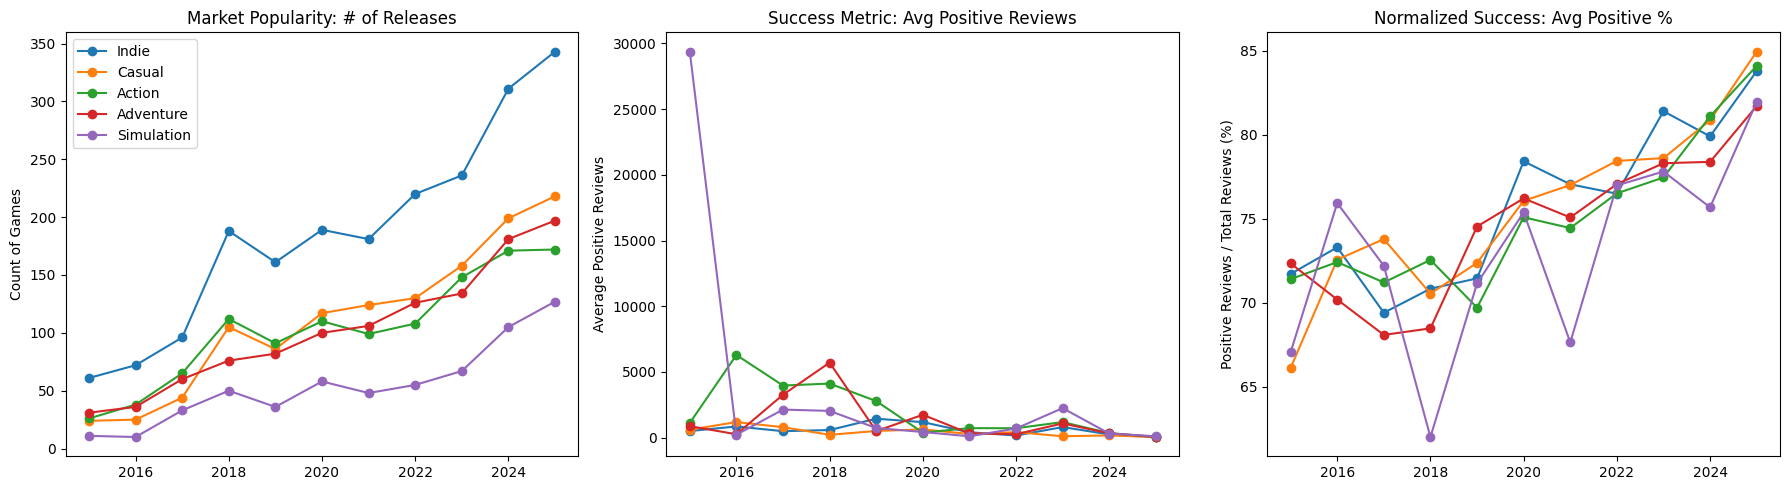

In [42]:
import matplotlib.pyplot as plt

# prepare the data: Convert date to Year and explode Genres
df_time = df.copy()
df_time['Release date'] = pd.to_datetime(df_time['Release date'], errors='coerce')
df_time['Release Year'] = df_time['Release date'].dt.year
df_time = df_time.dropna(subset=['Release Year', 'Genres'])

# explode genres so each genre gets its own row
df_time['Genres'] = df_time['Genres'].str.split(',')
df_time = df_time.explode('Genres')

# filter for the top 5 most common genres to keep the plot clean
top_5_genres = df_time['Genres'].value_counts().head(5).index
df_plot = df_time[df_time['Genres'].isin(top_5_genres)]

# filter for recent years (e.g., 2013-2023) for better visibility
df_plot = df_plot[(df_plot['Release Year'] >= 2015) & (df_plot['Release Year'] <= 2025)]

# pre-calculate the review percentage (normalized success)
df_plot['Positive'] = pd.to_numeric(df_plot['Positive'], errors='coerce')
df_plot['Negative'] = pd.to_numeric(df_plot['Negative'], errors='coerce')
df_plot['Total Reviews'] = df_plot['Positive'] + df_plot['Negative']
df_plot['Positive %'] = (df_plot['Positive'] / df_plot['Total Reviews']) * 100

# plot 1: Release Volume over time
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
for genre in top_5_genres:
    data = df_plot[df_plot['Genres'] == genre].groupby('Release Year').size()
    plt.plot(data.index, data.values, label=genre, marker='o')
plt.title('Market Popularity: # of Releases')
plt.ylabel('Count of Games')
plt.legend()

# plot 2: Success Metric (Avg Positive Reviews) over time
plt.subplot(1, 3, 2)
for genre in top_5_genres:
    data = df_plot[df_plot['Genres'] == genre].groupby('Release Year')['Positive'].mean()
    plt.plot(data.index, data.values, label=genre, marker='o')
plt.title('Success Metric: Avg Positive Reviews')
plt.ylabel('Average Positive Reviews')

# plot 3: Normalized Success (Avg Positive %)
plt.subplot(1, 3, 3)
for genre in top_5_genres:
    # We use a weighted mean or handle 0-review games to avoid bias
    data = df_plot[df_plot['Genres'] == genre].groupby('Release Year')['Positive %'].mean()
    plt.plot(data.index, data.values, label=genre, marker='o')
plt.title('Normalized Success: Avg Positive %')
plt.ylabel('Positive Reviews / Total Reviews (%)')

plt.tight_layout()
plt.show()

# What we see is that over time, the fastest growing category of games is the Indie category. Looking at the normalized public
# reception to the games, we see that over time all the top categories are consistently increasing.

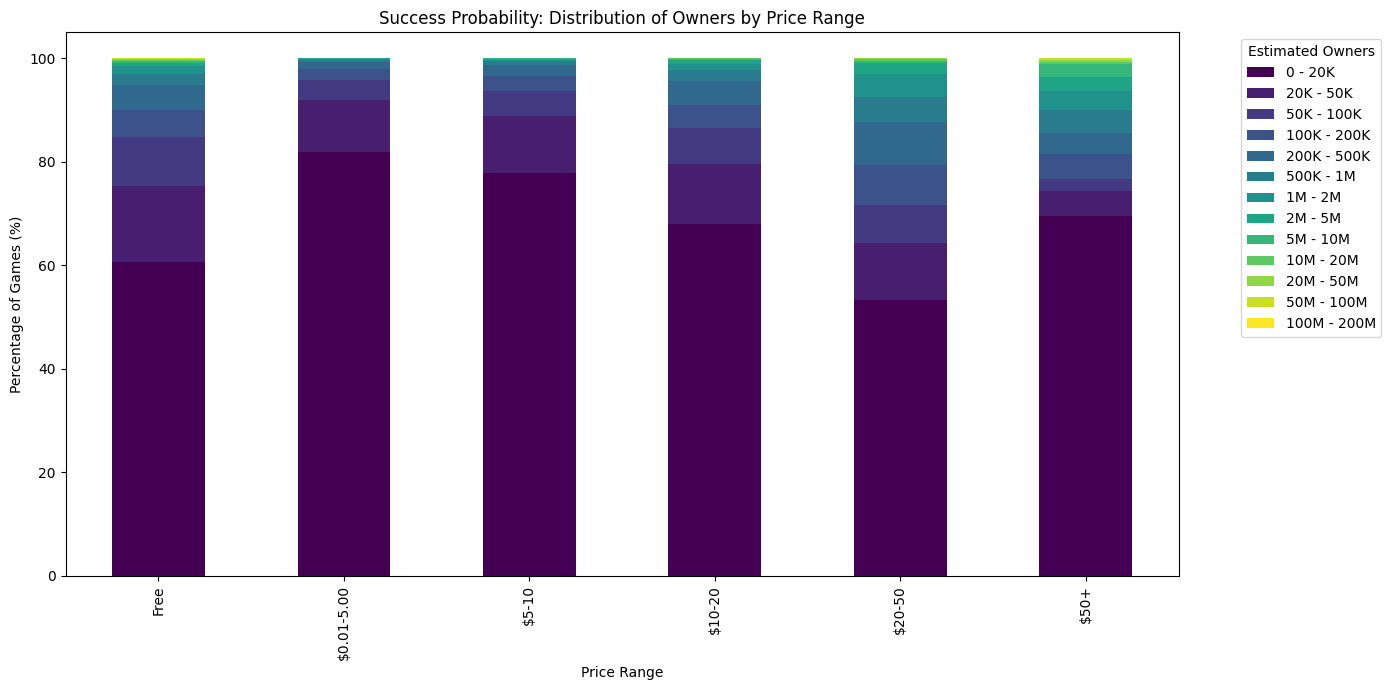

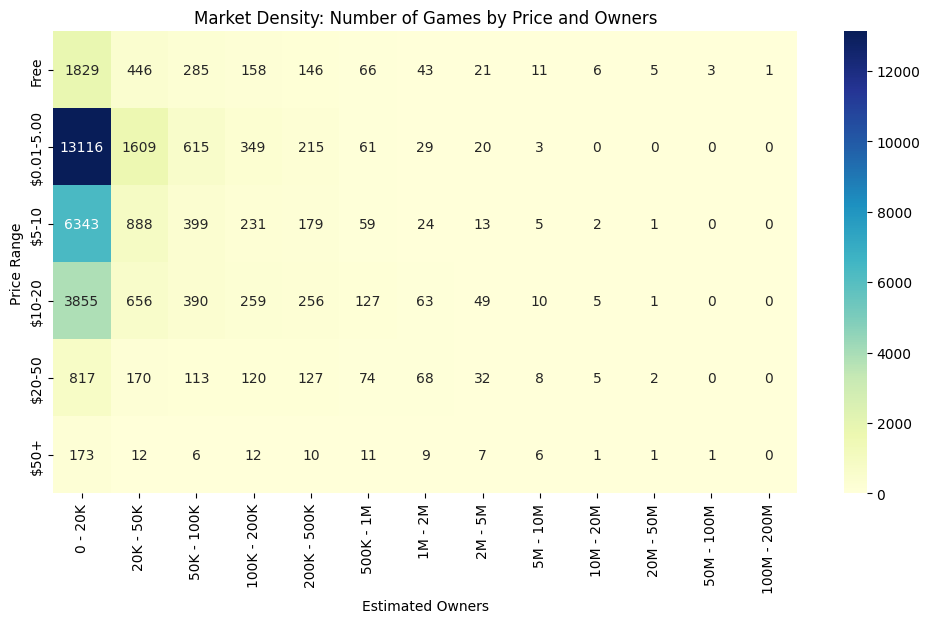

In [43]:
# clean Price and Create Bins
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').fillna(0)

price_bins = [-1, 0, 5, 10, 20, 50, 1000]
price_labels = ['Free', '$0.01-5.00', '$5-10', '$10-20', '$20-50', '$50+']
df['Price Range'] = pd.cut(df['Price'], bins=price_bins, labels=price_labels)

# create a Cross-tabulation of Price Range vs Estimated Owners
price_owner_counts = pd.crosstab(df['Price Range'], df['Estimated owners'])

# visualization 1: Success Probability (Stacked Bar Chart)
# normalize by row (Price Range) to show the percentage distribution
price_owner_pct = price_owner_counts.div(price_owner_counts.sum(1), axis=0) * 100

plt.figure(figsize=(14, 7))
price_owner_pct.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Success Probability: Distribution of Owners by Price Range')
plt.ylabel('Percentage of Games (%)')
plt.legend(title='Estimated Owners', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# visualization 2: market density (heatmap)
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(price_owner_counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Market Density: Number of Games by Price and Owners')
plt.ylabel('Price Range')
plt.xlabel('Estimated Owners')
plt.show()

# the stacked bar shows the 'probability' of success per price point, while the Heatmap shows the total volume of games

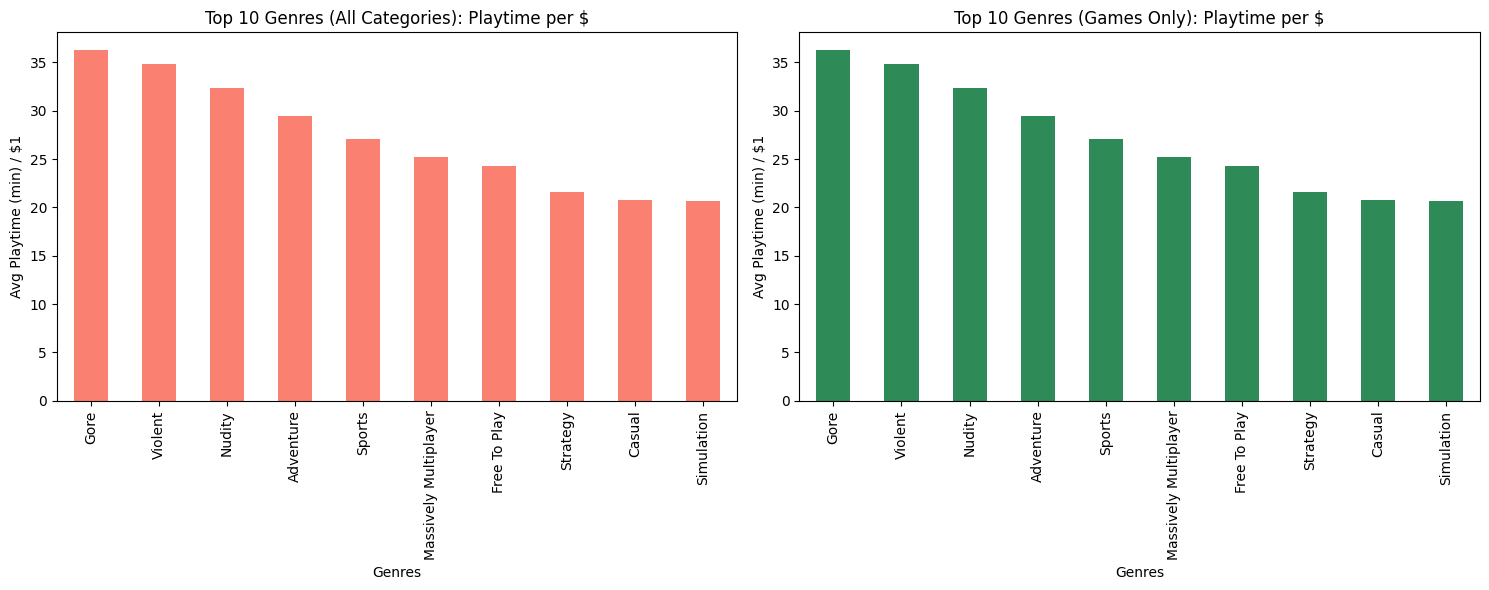

In [44]:
# question 3: Best Value

# calculate Playtime per Dollar
# filter for games > $0 to avoid division by zero
df_paid = df[df['Price'] > 0].copy()
df_paid['Median playtime forever'] = pd.to_numeric(df_paid['Median playtime forever'], errors='coerce').fillna(0)
df_paid['Playtime per Dollar'] = df_paid['Median playtime forever'] / df_paid['Price']

# prepare Genre Data
df_genres_val = df_paid.copy()
df_genres_val['Genres'] = df_genres_val['Genres'].str.split(',')
df_genres_val = df_genres_val.explode('Genres')

# visualization: All Genres vs. Games Only
plt.figure(figsize=(15, 6))

# plot 1: All Genres (including tools/utilities)
plt.subplot(1, 2, 1)
df_genres_val.groupby('Genres')['Playtime per Dollar'].mean().sort_values(ascending=False).head(10).plot.bar(color='salmon')
plt.title('Top 10 Genres (All Categories): Playtime per $')
plt.ylabel('Avg Playtime (min) / $1')

# plot 2: Games Only (Utility/Tool categories removed)
non_games = ['Audio Production', 'Utilities', 'Design & Illustration', 'Animation & Modeling', 'Video Production', 'Web Publishing', 'Software Training', 'Photo Editing']
df_games_only_val = df_genres_val[~df_genres_val['Genres'].isin(non_games)]

plt.subplot(1, 2, 2)
df_games_only_val.groupby('Genres')['Playtime per Dollar'].mean().sort_values(ascending=False).head(10).plot.bar(color='seagreen')
plt.title('Top 10 Genres (Games Only): Playtime per $')
plt.ylabel('Avg Playtime (min) / $1')

plt.tight_layout()
plt.show()

# The highest playtime per dollar spent is lead by MMO games by a large margin, whikle the rest of them trail behind.
# The utility/tool categories were filtered out because things like wallpaper engine may be left on 24/7 inflating the "playtime"

C:\Users\Patrick\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Patrick\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Patrick\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Patrick\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Patrick\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning:

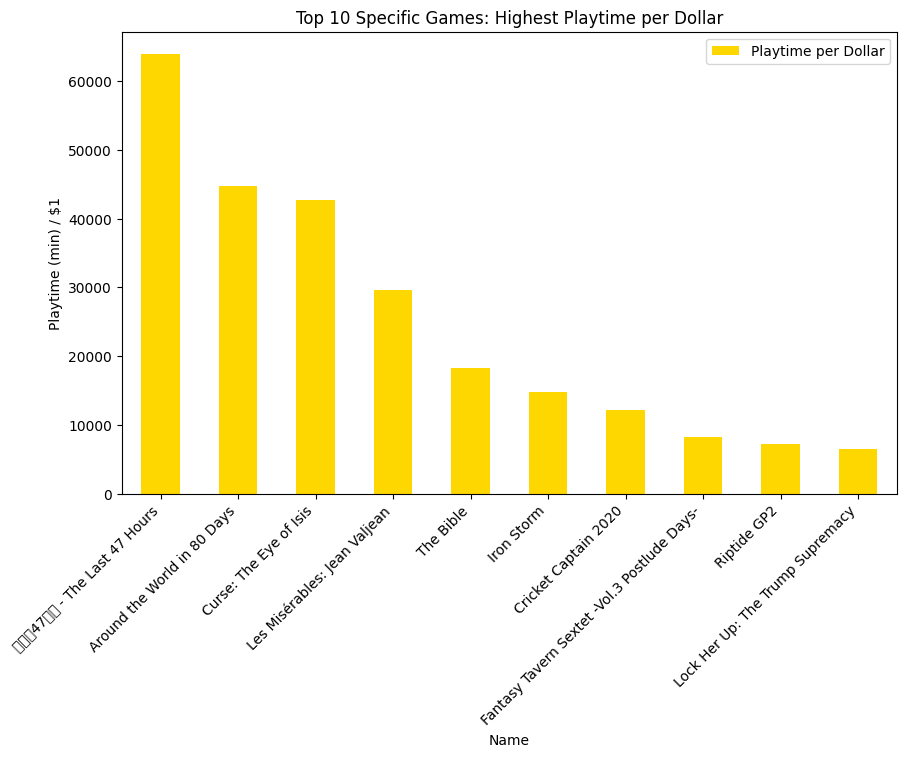

In [45]:
# top 10 best value specific games (paid games only)
plt.figure(figsize=(10, 6))
df_paid.sort_values(by='Playtime per Dollar', ascending=False)[['Name', 'Playtime per Dollar']].head(10).set_index('Name').plot.bar(color='gold', ax=plt.gca())
plt.title('Top 10 Specific Games: Highest Playtime per Dollar')
plt.ylabel('Playtime (min) / $1')
plt.xticks(rotation=45, ha='right')
plt.show()

# this is kind of useless, but I think the games it finds are funny

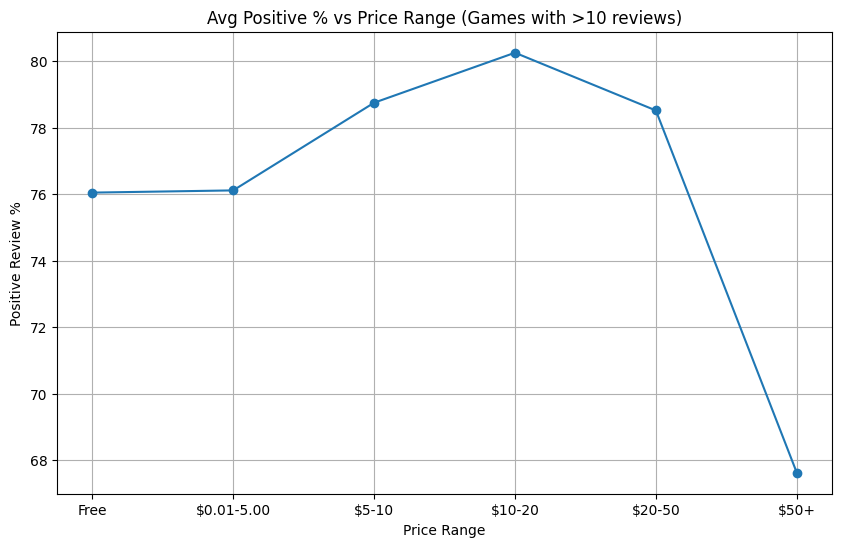

In [46]:
# Price vs User Sentiment
# do more expensive games get harsher reviews?
df['Positive'] = pd.to_numeric(df['Positive'], errors='coerce').fillna(0)
df['Negative'] = pd.to_numeric(df['Negative'], errors='coerce').fillna(0)
df['Total Reviews'] = df['Positive'] + df['Negative']
df['Positive %'] = (df['Positive'] / df['Total Reviews']) * 100

plt.figure(figsize=(10, 6))
df[df['Total Reviews'] > 10].groupby('Price Range', observed=False)['Positive %'].mean().plot.line(marker='o')
plt.title('Avg Positive % vs Price Range (Games with >10 reviews)')
plt.ylabel('Positive Review %')
plt.grid(True)
plt.show()

# For the most part games are generally well received across the price range, but users may be more critical of games with high 
# prices due to the fact that they expect more when they pay the premium to play it.

In [47]:
# question 4: Hidden Gems

# we define Hidden Gems as games that:
# 1. Have a small but significant number of reviews (50 to 2,000) to ensure community consensus while staying "hidden".
# 2. Have an exceptionally high positive review ratio (>95%).
# 3. Have at least 30 minutes of median playtime to filter out low-effort or botted games (idlers/card farmers).
# 4. Are ranked by their positive review percentage and total review count.

# The games we find here can be used as case studies for developers who want to see examples of other games
# which have found a distinct community that enjoys them and elements of their games that allow them to succeed.

# 1. Calculate Total Reviews and Positive Ratio
df['Total Reviews'] = df['Positive'] + df['Negative']
df['Positive %'] = (df['Positive'] / df['Total Reviews']) * 100

# 2. Define Hidden Gems criteria
min_reviews = 50
max_reviews = 2000
min_positive_ratio = 95
min_median_playtime = 30 # minutes

hidden_gems = df[
    (df['Total Reviews'] >= min_reviews) &
    (df['Total Reviews'] <= max_reviews) &
    (df['Positive %'] >= min_positive_ratio) &
    (df['Median playtime forever'] >= min_median_playtime)
].copy()

# 3. Sort by Positive % and then Total Reviews to find the best of the best
hidden_gems = hidden_gems.sort_values(by=['Positive %', 'Total Reviews'], ascending=[False, False])

# 4. Display the top 20 Hidden Gems
display_cols = ['Name', 'Positive %', 'Total Reviews', 'Median playtime forever', 'Price', 'Genres']
print(f"Found {len(hidden_gems)} hidden gems.")
hidden_gems[display_cols].head(20)

Found 370 hidden gems.


,Name,Positive %,Total Reviews,Median playtime forever,Price,Genres
33785,MareQuest: An Interactive Tail,100.000000,190,159,4.99,"Adventure,Casual,Indie,RPG"
31722,PRODUCER 2021,100.000000,167,32,9.99,"Adventure,RPG,Simulation"
31440,TETRACHROMA,100.000000,151,1484,4.99,"Action,Casual"
23703,Supurr Cat Cafe: Sandwich Rush,100.000000,79,137,5.99,"Casual,Indie"
20088,Gordy and the Monster Moon,100.000000,69,62,3.99,"Action,Adventure,Indie"
24147,Sable's Grimoire: A Dragon's Treasure,100.000000,68,495,5.99,"Casual,Indie,Simulation"
24264,Axyz,100.000000,68,49,11.99,"Casual,Indie"
15199,Sakura Succubus 8,100.000000,64,122,9.99,Simulation
23825,An Architect's Adventure,100.000000,54,184,5.99,"Casual,Indie"
34406,Imaginary Friend Asylum,100.000000,51,234,4.99,"Action,Adventure,Indie,Simulation"


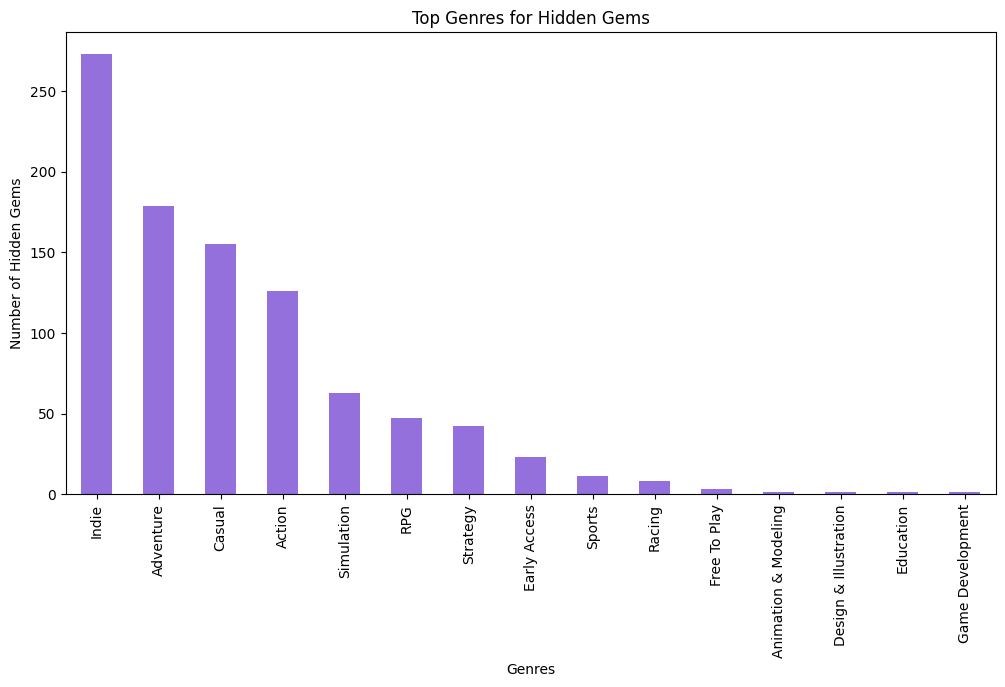

In [48]:
# visualizing the distribution of Hidden Gems across Genres
if not hidden_gems.empty:
    gems_exploded = hidden_gems.copy()
    gems_exploded['Genres'] = gems_exploded['Genres'].str.split(',')
    gems_exploded = gems_exploded.explode('Genres')
    
    plt.figure(figsize=(12, 6))
    gems_exploded['Genres'].value_counts().head(15).plot.bar(color='mediumpurple')
    plt.title('Top Genres for Hidden Gems')
    plt.ylabel('Number of Hidden Gems')
    plt.show()
else:
    print("No hidden gems found with the current criteria.")

In [49]:

# question 5: Cult Classics

# we define Cult Classics as games that:
# 1. Have a moderate but not massive player base (20K to 500K estimated owners).
# 2. Have a high positive review ratio (>80%) to ensure they are actually good games.
# 3. Have exceptionally high median playtime (>1,000 minutes) relative to their player count, indicating a very dedicated fanbase.
# 4. Exclude non-game categories like utilities or tools.

# Cult Classics criteria
cult_owner_brackets = ['20K - 50K', '50K - 100K', '100K - 200K']
min_cult_positive_ratio = 90
min_cult_median_playtime = 1000 # minutes

# filter the dataframe

# remove the non-game categories
non_games = ['Audio Production', 'Utilities', 'Design & Illustration', 'Animation & Modeling', 'Video Production', 'Web Publishing', 'Software Training', 'Photo Editing']

cult_classics = df[
    (df['Estimated owners'].isin(cult_owner_brackets)) &
    (df['Positive %'] >= min_cult_positive_ratio) &
    (df['Median playtime forever'] >= min_cult_median_playtime) &
    (~df['Genres'].str.contains('|'.join(non_games), na=False))
].copy()

# sort by Median playtime forever to see the most engaging games first
cult_classics = cult_classics.sort_values(by='Median playtime forever', ascending=False)

# display the top 20 Cult Classics
print(f"Found {len(cult_classics)} cult classics.")
cult_classics[['Name', 'Estimated owners', 'Positive %', 'Total Reviews', 'Median playtime forever', 'Genres']].head(20)

Found 71 cult classics.


,Name,Estimated owners,Positive %,Total Reviews,Median playtime forever,Genres
10404,最后的47小时 - The Last 47 Hours,20K - 50K,94.227994,693,127292,Adventure
3171,Railroader,100K - 200K,97.369396,2699,15279,"Simulation,Strategy,Early Access"
31375,LandTraveller,20K - 50K,91.780822,73,8704,"Indie,RPG,Early Access"
28291,Lost Artifacts - Ancient Tribe Survival,20K - 50K,92.857143,98,7859,"Action,Adventure,Casual,Indie,Simulation,Strategy"
3093,9-nine-:Episode 3,20K - 50K,91.905355,803,7316,"Action,Casual,Simulation"
4706,Sankaku Renai: Love Triangle Trouble,50K - 100K,94.800000,250,5632,"Adventure,Casual,Simulation"
14777,Hero-U: Rogue to Redemption,50K - 100K,92.519685,508,4523,"Adventure,Indie,RPG"
6005,Winds of Change,20K - 50K,95.714286,560,4155,"Adventure,Indie,RPG"
21963,Tennis Elbow 4,20K - 50K,94.930876,651,3754,"Indie,Simulation,Sports"
12251,Wylde Flowers,50K - 100K,96.233027,2283,3436,"Adventure,Simulation"


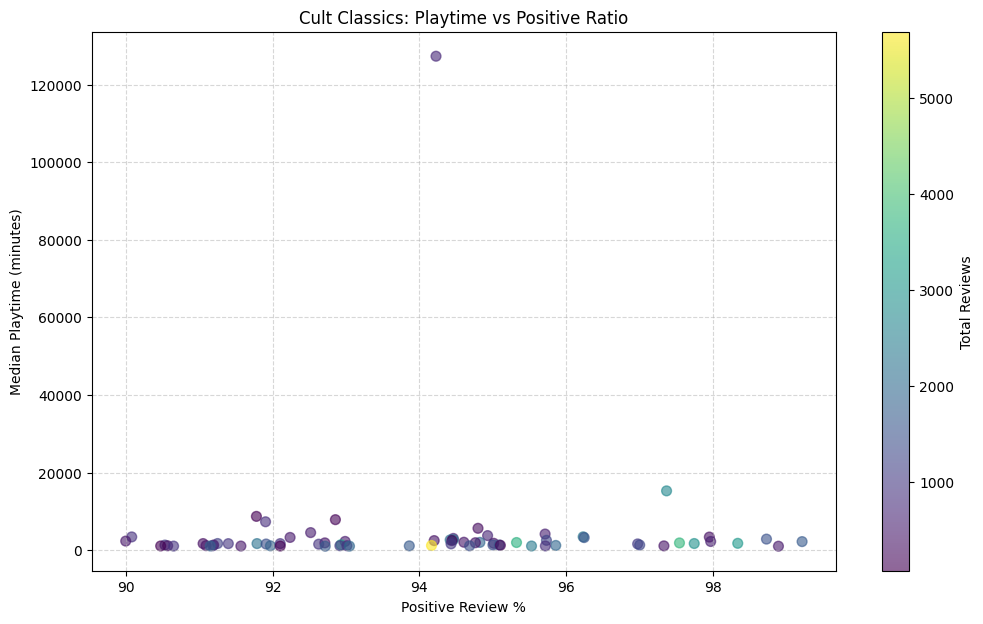

In [50]:
# visualizing Median Playtime vs Positive Ratio for Cult Classics
if not cult_classics.empty:
    plt.figure(figsize=(12, 7))
    scatter = plt.scatter(cult_classics['Positive %'], cult_classics['Median playtime forever'], 
                          alpha=0.6, c=cult_classics['Total Reviews'], cmap='viridis', s=50)
    plt.title('Cult Classics: Playtime vs Positive Ratio')
    plt.xlabel('Positive Review %')
    plt.ylabel('Median Playtime (minutes)')
    plt.colorbar(scatter, label='Total Reviews')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
else:
    print("No cult classics found with the current criteria.")

In [51]:
# Developer Inspiration Dashboard (probably better to do this in tableau)

# This section organizes our findings into actionable categories for developers looking for inspiration.
# We focus on Recent (Last 5 Years) Cult Classics and Hidden Gems, grouped by the most popular genres. 
# This highlights modern design patterns that are successfully capturing and retaining dedicated 
# audiences.


# prepare Data: Add Year and calculate Engagement Score
df_dev = df.copy()
df_dev['Release date'] = pd.to_datetime(df_dev['Release date'], errors='coerce')
df_dev['Release Year'] = df_dev['Release date'].dt.year

# engagement Score = (Normalized Playtime * Positive Ratio)
# use log of playtime to handle outliers while rewarding high engagement
import numpy as np
df_dev['Engagement Score'] = np.log1p(df_dev['Median playtime forever']) * (df_dev['Positive %'] / 100)

# filter for Recent Classics (Released 2019+)
recent_hits = df_dev[
    (df_dev['Release Year'] >= 2019) &
    (df_dev['Positive %'] >= 90) &
    ((df_dev['Total Reviews'] >= 50) | (df_dev['Median playtime forever'] >= 500))
].copy()

# identify Top 5 Genres by Volume
top_genres = ['Action', 'Indie', 'Adventure', 'RPG', 'Strategy'] # Based on earlier analysis

# create the Dashboard: Top 3 Inspiration Games per Genre
inspiration_list = []

for genre in top_genres:
    genre_subset = recent_hits[recent_hits['Genres'].str.contains(genre, na=False)].sort_values(by='Engagement Score', ascending=False)
    
    # Get top 3
    top_3 = genre_subset.head(3).copy()
    top_3['Focus Genre'] = genre
    inspiration_list.append(top_3)

dashboard_df = pd.concat(inspiration_list)
dashboard_df = dashboard_df[['Focus Genre', 'Name', 'Release Year', 'Positive %', 'Median playtime forever', 'Estimated owners', 'Price']]

print("Top Modern Inspiration Games (Cult Classics & Hidden Gems) by Genre:")
dashboard_df.set_index(['Focus Genre', 'Name'])

Top Modern Inspiration Games (Cult Classics & Hidden Gems) by Genre:


Release Year  \
Focus Genre Name                                                        
Action      Alien Market Simulator                             2025.0   
            Garden of Witches                                  2025.0   
            Rabbit and Steel                                   2024.0   
Indie       Fantasy Tavern Sextet -Vol.3 Postlude Days-        2021.0   
            Gentoo Rescue                                      2025.0   
            Ninja Village                                      2022.0   
Adventure   Fantasy Tavern Sextet -Vol.3 Postlude Days-        2021.0   
            Sankaku Renai: Love Triangle Trouble               2019.0   
            Tsuki ni Yorisou Otome no Sahou 2                  2025.0   
RPG         Ninja Village                                      2022.0   
            Fuga: Melodies of Steel 3                          2025.0   
            Esports Godfather                                  2024.0   
Strategy    Close Combat 2: A Bridge Too Far                   2024.0   
            Gentoo Rescue                                      2025.0   
            Ninja Village                                      2022.0   

                                                         Positive %  \
Focus Genre Name                                                      
Action      Alien Market Simulator                        93.617021   
            Garden of Witches                             96.184739   
            Rabbit and Steel                              97.279302   
Indie       Fantasy Tavern Sextet -Vol.3 Postlude Days-   91.428571   
            Gentoo Rescue                                100.000000   
            Ninja Village                                 94.036697   
Adventure   Fantasy Tavern Sextet -Vol.3 Postlude Days-   91.428571   
            Sankaku Renai: Love Triangle Trouble          94.800000   
            Tsuki ni Yorisou Otome no Sahou 2             96.356275   
RPG         Ninja Village                                 94.036697   
            Fuga: Melodies of Steel 3                     97.727273   
            Esports Godfather                             91.976464   
Strategy    Close Combat 2: A Bridge Too Far              93.750000   
            Gentoo Rescue                                100.000000   
            Ninja Village                                 94.036697   

                                                         Median playtime forever  \
Focus Genre Name                                                                   
Action      Alien Market Simulator                                           691   
            Garden of Witches                                                454   
            Rabbit and Steel                                                 411   
Indie       Fantasy Tavern Sextet -Vol.3 Postlude Days-                   107448   
            Gentoo Rescue                                                   1673   
            Ninja Village                                                   2334   
Adventure   Fantasy Tavern Sextet -Vol.3 Postlude Days-                   107448   
            Sankaku Renai: Love Triangle Trouble                            5632   
            Tsuki ni Yorisou Otome no Sahou 2                               3233   
RPG         Ninja Village                                                   2334   
            Fuga: Melodies of Steel 3                                       1710   
            Esports Godfather                                               2501   
Strategy    Close Combat 2: A Bridge Too Far                                3656   
            Gentoo Rescue                                                   1673   
            Ninja Village                                                   2334   

                                                        Estimated owners  \
Focus Genre Name                                                           
Action      Alien Market S

In [52]:
# export important dataframes for tableau

# main cleaned dataset
df.to_csv('cleaned_steam_games.csv', index=False)

# platform support analysis
df_system_support.to_csv('platform_support_analysis.csv')

# genre popularity analysis
genre_fraction_per_owner.to_csv('genre_popularity_analysis.csv')

# hidden gems
hidden_gems.to_csv('hidden_gems.csv', index=False)

# cult classics
cult_classics.to_csv('cult_classics.csv', index=False)

# modern inspiration games
dashboard_df.to_csv('modern_inspiration_games.csv', index=False)